In [33]:
%pip install -q tensorflow tensorflow-hub tensorflow-text imblearn

In [35]:
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

In [36]:
try:
    df = pd.read_csv("./datasets/spam.csv")
except FileNotFoundError:
    df = pd.read_csv(
        "https://raw.githubusercontent.com/amankharwal/SMS-Spam-Detection/master/spam.csv",
        encoding="latin-1",
    )
    df.rename(columns={"class": "Category", "message": "Message"}, inplace=True)
df = df[["Category", "Message"]]
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [37]:
df["Category"].value_counts()

,count
Category,
ham,4825
spam,747


In [38]:
df["Category"] = df["Category"].map({"spam": 1, "ham": 0})
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [39]:
from imblearn.over_sampling import SMOTEN

smote = SMOTEN(sampling_strategy="auto", random_state=42)
X, y = smote.fit_resample(df[["Message"]], df["Category"])
df = pd.DataFrame({"Message": X["Message"], "Spam": y})
df

,Message,Spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
9645,December only! Had your mobile 11mths+? You ar...,1
9646,December only! Had your mobile 11mths+? You ar...,1
9647,December only! Had your mobile 11mths+? You ar...,1
9648,December only! Had your mobile 11mths+? You ar...,1


In [40]:
# import spacy

# nlp = spacy.load("en_core_web_sm")


# def preprocess(text):
#     doc = nlp(text)

#     text = [
#         str(token.lemma_)
#         for token in doc
#         if not token.is_space and not token.is_punct and not token.is_stop
#     ]

#     return " ".join(text)

# df["Message"] = df["Message"].apply(preprocess)
# df

In [41]:
preprocessor_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
encoder_url = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

In [42]:
bert_preprocessor = hub.KerasLayer(preprocessor_url)

In [43]:
sample = str(df.loc[0, "Message"])
[sample]

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...']

In [44]:
sample_emdedded_text = bert_preprocessor([sample])
sample_emdedded_text.keys()

dict_keys(['input_type_ids', 'input_mask', 'input_word_ids'])

In [45]:
sample_emdedded_text["input_type_ids"]

<tf.Tensor: shape=(1, 128), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)>

In [46]:
sample_emdedded_text["input_mask"]

<tf.Tensor: shape=(1, 128), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)>

In [47]:
sample_emdedded_text["input_word_ids"]

<tf.Tensor: shape=(1, 128), dtype=int32, numpy=
array([[  101,  2175,  2127, 18414, 17583,  2391,  1010,  4689,  1012,
         1012,  2800,  2069,  1999, 11829,  2483,  1050,  2307,  2088,
         2474,  1041, 28305,  1012,  1012,  1012, 25022,  2638,  2045,
         2288, 26297, 28194,  1012,  1012,  1012,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

In [48]:
len(sample.split(" "))

20

In [49]:
bert_model = hub.KerasLayer(encoder_url)
bert_model

In [50]:
encoded_df = bert_model(sample_emdedded_text)
encoded_df.keys()

dict_keys(['pooled_output', 'sequence_output', 'encoder_outputs', 'default'])

In [51]:
encoded_df["pooled_output"]

<tf.Tensor: shape=(1, 768), dtype=float32, numpy=
array([[-6.92833662e-01, -3.82204175e-01, -9.52783823e-01,
         7.51712024e-01,  8.26993704e-01, -1.11341342e-01,
         7.74034083e-01,  3.49266708e-01, -8.27566504e-01,
        -9.99938250e-01, -4.91910964e-01,  8.27597499e-01,
         9.51055944e-01,  5.97681224e-01,  8.68827105e-01,
        -6.57568932e-01, -2.09729776e-01, -5.72027445e-01,
         3.47762346e-01, -8.90982524e-02,  7.33236611e-01,
         9.99997258e-01, -3.19866762e-02,  3.63329351e-01,
         4.31966245e-01,  9.74061131e-01, -6.39868021e-01,
         8.87976885e-01,  9.05901551e-01,  6.73174083e-01,
        -6.16901994e-01,  1.64389208e-01, -9.71923470e-01,
        -2.86567330e-01, -9.75934803e-01, -9.69695449e-01,
         3.52540255e-01, -4.34979498e-01, -7.32299015e-02,
         1.02228612e-01, -8.72294605e-01,  2.68635213e-01,
         9.99939263e-01,  1.91500857e-01,  5.27790487e-01,
        -2.25496992e-01, -9.99999046e-01,  2.58211255e-01,
      

In [52]:
encoded_df["sequence_output"]


<tf.Tensor: shape=(1, 128, 768), dtype=float32, numpy=
array([[[-0.1512544 , -0.32118288,  0.1855121 , ..., -0.5068801 ,
          0.63901407,  0.54487383],
        [ 0.10730401, -0.8289801 ,  0.48391855, ..., -0.3149336 ,
          0.5076803 ,  0.5815216 ],
        [-0.5107361 , -0.8040781 ,  0.77403367, ..., -0.78598607,
          0.06210787,  0.12463576],
        ...,
        [ 0.00711231, -0.21791308,  0.6729245 , ..., -0.07194308,
          0.09299343, -0.02251498],
        [-0.2107368 , -0.6922681 ,  0.24071333, ...,  0.14590272,
          0.29038453, -0.15658152],
        [ 0.03077302, -0.36702287,  0.67560357, ..., -0.12556894,
          0.14143541, -0.06488999]]], dtype=float32)>

In [53]:
encoded_df["encoder_outputs"]


[<tf.Tensor: shape=(1, 128, 768), dtype=float32, numpy=
 array([[[-0.02203291,  0.0763738 , -0.13984004, ...,  0.22147065,
          -0.11716789, -0.0480399 ],
         [-1.322942  , -0.96670216, -1.110043  , ...,  0.3521741 ,
          -0.17874922,  1.0060763 ],
         [-1.1977078 ,  0.74466455, -0.3405473 , ..., -0.74329907,
           1.0972639 ,  0.845944  ],
         ...,
         [-0.15716067, -0.27590042,  0.5938901 , ...,  0.39390635,
          -0.2924902 ,  0.01900818],
         [-0.23327339, -0.27323493,  0.48454976, ...,  0.40963417,
          -0.2239421 , -0.07876518],
         [-0.09683915, -0.20648608,  0.51210266, ...,  0.719289  ,
          -0.5253212 , -0.15784548]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 128, 768), dtype=float32, numpy=
 array([[[-0.08849424, -0.25860438, -0.3249261 , ...,  0.518202  ,
           0.01539404, -0.02016555],
         [-1.5743781 , -0.66080844, -0.88075095, ...,  0.02201873,
           0.16972515,  0.9359687 ],
         [-1.6697093 , 

In [54]:
encoded_df["encoder_outputs"][-1] == encoded_df["sequence_output"]

<tf.Tensor: shape=(1, 128, 768), dtype=bool, numpy=
array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]])>

### Spam Classification

In [55]:
from sklearn.model_selection import train_test_split

X = df["Message"]
y = df["Spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [56]:
preprocessor_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
encoder_url = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

bert_preprocessor = hub.KerasLayer(preprocessor_url, name="preprocessing")
bert_model = hub.KerasLayer(encoder_url, trainable=False, name="BERT_encoder")

In [57]:
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")

bert_input = bert_preprocessor(text_input)
bert_output = bert_model(bert_input)

x = bert_output["pooled_output"]
x = tf.keras.layers.Dropout(0.2)(x)

output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=text_input, outputs=output_layer)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [58]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

In [59]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
242/242 [==============================] - 88s 328ms/step - loss: 0.3232 - accuracy: 0.8994 - precision: 0.8794 - recall: 0.9256
Epoch 2/5
242/242 [==============================] - 81s 336ms/step - loss: 0.1562 - accuracy: 0.9553 - precision: 0.9512 - recall: 0.9598
Epoch 3/5
242/242 [==============================] - 83s 342ms/step - loss: 0.1215 - accuracy: 0.9626 - precision: 0.9649 - recall: 0.9601
Epoch 4/5
242/242 [==============================] - 82s 338ms/step - loss: 0.1029 - accuracy: 0.9679 - precision: 0.9715 - recall: 0.9640
Epoch 5/5
242/242 [==============================] - 75s 309ms/step - loss: 0.0929 - accuracy: 0.9720 - precision: 0.9775 - recall: 0.9663


In [60]:
model.evaluate(X_test, y_test)

61/61 [==============================] - 20s 304ms/step - loss: 0.0745 - accuracy: 0.9736 - precision: 0.9851 - recall: 0.9617


[0.07450637221336365,
 0.9735751152038574,
 0.9851379990577698,
 0.9616580605506897]

In [63]:
y_hat = model.predict(X_test)
y_hat = [1 if y > 0.5 else 0 for y in y_hat]


61/61 [==============================] - 23s 328ms/step


In [64]:
y_hat[:10]

[1, 0, 1, 1, 0, 1, 1, 0, 1, 1]

In [79]:
%pip install -q matplotlib seaborn catppuccin

Text(95.72222222222221, 0.5, 'Actual')

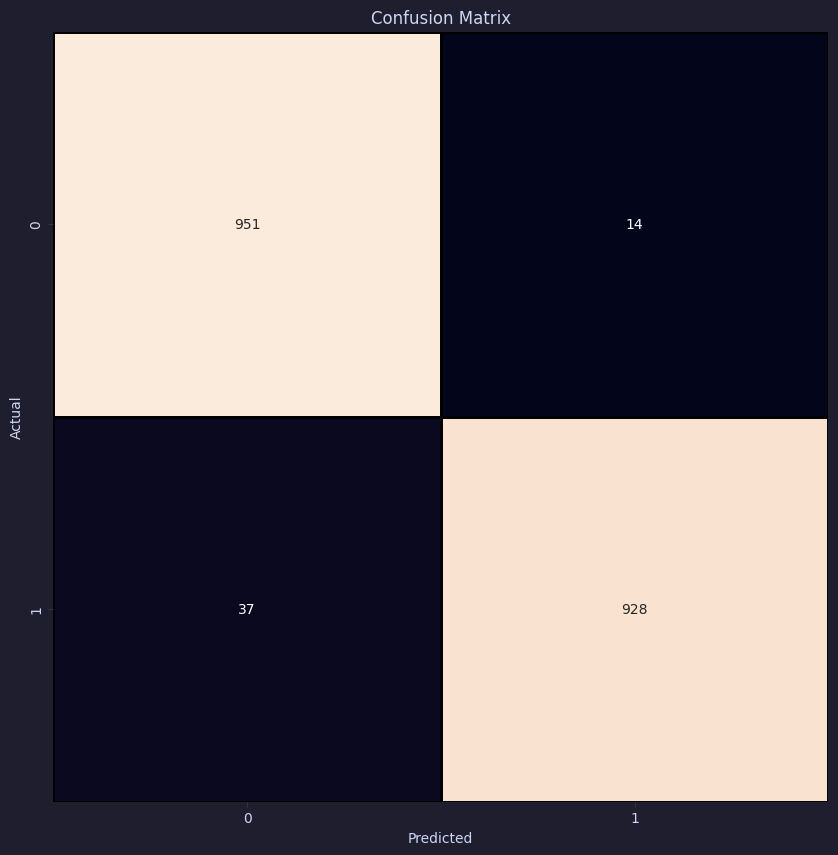

In [ ]:
import catppuccin
import matplotlib.pyplot as plt
from seaborn import heatmap
from sklearn.metrics import confusion_matrix

matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])

cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(10, 10))
heatmap(cm, annot=True, fmt="d", cbar=False, linecolor="black", linewidth="1")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")